### CEAD (Centro de Estudios y Análisis del Delito, de la Subsecretaría de Prevención del Delito) es el organismo oficial de estadísticas criminales de Chile — es el "CONASET de la criminalidad". Publica casos policiales por comuna desde 2005. 
- CEAD no publica la ubicación exacta de cada delito por proteccion de datos
-  Revelar el punto exacto de un delito (como un caso de violencia intrafamiliar o un robo residencial) permitiría identificar fácilmente a las víctimas o testigos, vulnerando las leyes de protección de la vida privada.

In [1]:
# pip install pyarrow  (si no lo tienen instalado, para leer parquet)
import pandas as pd

url = "https://github.com/bastianolea/delincuencia_chile/raw/main/datos/procesados/cead_delincuencia_chile.parquet"
delitos = pd.read_parquet(url)

print(delitos.shape)
print(delitos.columns.tolist())
delitos.head()

(1987200, 7)
['comuna', 'cut_comuna', 'region', 'cut_region', 'fecha', 'delito', 'delito_n']


,comuna,cut_comuna,region,cut_region,fecha,delito,delito_n
0,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Abusos sexuales,0.0
1,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Acosos sexuales,0.0
2,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Amenaza falta o riña,3.0
3,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Amenazas,4.0
4,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Consumo de alcohol y drogas en la vía pública,67.0


In [2]:
print(delitos.shape)
print(delitos.columns.tolist())
print(delitos.dtypes)
delitos.head(10)

(1987200, 7)
['comuna', 'cut_comuna', 'region', 'cut_region', 'fecha', 'delito', 'delito_n']
comuna        category
cut_comuna     float64
region        category
cut_region     float64
fecha           object
delito        category
delito_n       float64
dtype: object


,comuna,cut_comuna,region,cut_region,fecha,delito,delito_n
0,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Abusos sexuales,0.0
1,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Acosos sexuales,0.0
2,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Amenaza falta o riña,3.0
3,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Amenazas,4.0
4,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Consumo de alcohol y drogas en la vía pública,67.0
5,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Crímenes y simples delitos ley de armas,0.0
6,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Daños,18.0
7,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Delitos asociados a armas,0.0
8,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Delitos asociados a drogas,0.0
9,Aisén,11201.0,Aysén del General Carlos Ibáñez del Campo,11.0,2010-01-01,Desórdenes públicos,5.0


In [3]:
# Nulos y duplicados
print(delitos.isnull().sum()[delitos.isnull().sum() > 0])
print('\nDuplicados exactos:', delitos.duplicated().sum())

Series([], dtype: int64)

Duplicados exactos: 0


In [4]:
# Fecha a datetime, y ver rango + tipos de delito disponibles
delitos['fecha'] = pd.to_datetime(delitos['fecha'])

print('Rango de fechas:', delitos['fecha'].min(), 'a', delitos['fecha'].max())
print('\nTipos de delito (30 esperados):')
print(delitos['delito'].unique())

Rango de fechas: 2010-01-01 00:00:00 a 2025-12-01 00:00:00

Tipos de delito (30 esperados):
['Abusos sexuales', 'Acosos sexuales', 'Amenaza falta o riña', 'Amenazas', 'Consumo de alcohol y drogas en la vía pública', ..., 'Robo violento de vehículo motorizado', 'Robos con violencia o intimidación', 'Robo en lugar no habitado', 'Violaciones', 'Violencia intrafamiliar']
Length: 30
Categories (30, object): ['Abusos sexuales', 'Acosos sexuales', 'Amenaza falta o riña', 'Amenazas', ..., 'Robos con violencia o intimidación', 'Robo en lugar no habitado', 'Violaciones', 'Violencia intrafamiliar']


In [5]:
# Regiones disponibles (para filtrar RM con el nombre exacto)
print(delitos['region'].unique())

['Aysén del General Carlos Ibáñez del Campo', 'Valparaíso', 'Metropolitana de Santiago', 'Biobío', 'Atacama', ..., 'Ñuble', 'Magallanes y de la Antártica Chilena', 'Maule', 'Libertador Gral. Bernardo O'Higgins', 'Los Ríos']
Length: 16
Categories (16, object): ['Antofagasta', 'Arica y Parinacota', 'Atacama', 'Aysén del General Carlos Ibáñez del Campo', ..., 'Metropolitana de Santiago', 'Ñuble', 'Tarapacá', 'Valparaíso']


In [6]:
# Filtrar la Región Metropolitana
rm_delitos = delitos[delitos['region'] == 'Metropolitana de Santiago'].copy()  # ajusta el nombre exacto según la celda anterior
print(rm_delitos.shape)
print('Comunas en la RM:', rm_delitos['comuna'].nunique())

(299520, 7)
Comunas en la RM: 52


In [7]:
# Nos quedamos con los últimos 12 meses disponibles, para tener una "foto" reciente por comuna
# (sumar los 15 años completos mezclaría contextos muy distintos de criminalidad)
ultimo_mes = rm_delitos['fecha'].max()
periodo = rm_delitos[rm_delitos['fecha'] > ultimo_mes - pd.DateOffset(months=12)]
print('Período:', periodo['fecha'].min(), 'a', periodo['fecha'].max())

# Total de casos por comuna (todos los delitos sumados)
total_comuna = periodo.groupby(['comuna', 'cut_comuna'], observed=True)['delito_n'].sum().reset_index(name='total_delitos')
total_comuna.sort_values('total_delitos', ascending=False).head(10)

Período: 2025-01-01 00:00:00 a 2025-12-01 00:00:00


,comuna,cut_comuna,total_delitos
48,Santiago,13101.0,48285.039
37,Puente Alto,13201.0,26570.000
25,Maipú,13119.0,23595.000
15,La Florida,13110.0,19656.000
42,San Bernardo,13401.0,19195.000
10,Estación Central,13106.0,16016.000
35,Providencia,13123.0,15550.000
36,Pudahuel,13124.0,14143.000
28,Ñuñoa,13120.0,13650.000
40,Recoleta,13127.0,13047.000


In [11]:
censo = pd.read_csv(r"C:\Users\valeria.ulloa\Documents\trabajo_varios\DIPLOMADO_ANALISIS_ESPACIAL\diplomado_2026\segunda_parte\personas_censo2024.csv", sep = ";")

In [12]:
censo.shape

(18480432, 63)

In [13]:
censo.head(2)

,id_vivienda,id_hogar,id_persona,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,sexo,...,p45_medio_transporte,p46a_tot_hijs_nac,p46b_hijas_nac,p46c_hijos_nac,p47a_tot_hijs_sobrev,p47b_hijas_sobrev,p47c_hijos_sobrev,p48_anio_nac_uh,p48_mes_nac_uh,div_genero
0,1,1,1,5,58,5802,2,1,2,2,...,NaN,3.0,2.0,1.0,3.0,2.0,1.0,1978.0,7.0,2.0
1,1,1,2,5,58,5802,2,1,2,1,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [16]:
censo.columns

Index(['id_vivienda', 'id_hogar', 'id_persona', 'region', 'provincia',
       'comuna', 'comuna_bajo_umbral', 'area', 'tipo_operativo', 'sexo',
       'edad', 'edad_quinquenal', 'parentesco', 'p23_est_civil',
       'p24_lug_resid5', 'p24_lug_resid5_esp', 'p25_lug_nacimiento',
       'p25_lug_nacimiento_rec', 'p25_lug_nacimiento_esp',
       'p26_llegada_periodo', 'p27_nacionalidad', 'p27_nacionalidad_esp',
       'p27_nacionalidad_rec', 'p28_autoid_pueblo', 'p28_pueblo_pert',
       'p29_afrodescendencia_rec', 'p29_afrodescendencia',
       'p30_lengua_indigena', 'p30_lengua_indigena_rec', 'p31_religion',
       'p31_religion_rec', 'p32a_dificultad_ver', 'p32b_dificultad_oir',
       'p32c_dificultad_mover', 'p32d_dificultad_cogni',
       'p32e_dificultad_cuidado', 'p32f_dificultad_comunic', 'discapacidad',
       'p33_edu_asiste', 'asistencia_parv', 'asistencia_basica',
       'asistencia_media', 'asistencia_superior', 'p37_alfabet', 'escolaridad',
       'cine11', 'sit_fuerza_traba

In [30]:
# Población total por comuna: cada fila es una persona, así que contar filas = población
poblacion_comuna = censo.groupby(['region', 'comuna'], observed=True).size().reset_index(name='poblacion').copy()
poblacion_comuna.sort_values('poblacion', ascending=False).head(10)

,region,comuna,poblacion
289,13,13201,568086
275,13,13119,503635
257,13,13101,438856
7,2,2101,401096
266,13,13110,374836
46,5,5109,334871
295,13,13401,306371
270,13,13114,296134
174,9,9101,292518
40,5,5101,284938


In [31]:
# Filtrar solo la RM (usa el nombre exacto que aparezca en 'region')
print(censo['region'].unique())

[ 5  4 11  1  8 13 14  9  7 10  3 12  2  6 16 15]


In [32]:
poblacion_rm = poblacion_comuna[poblacion_comuna['region'] == 13]  # ajusta el nombre según la celda de arriba
print('Comunas en la RM:', len(poblacion_rm))
poblacion_rm.sort_values('poblacion', ascending=False)

Comunas en la RM: 52


,region,comuna,poblacion
289,13,13201,568086
275,13,13119,503635
257,13,13101,438856
266,13,13110,374836
295,13,13401,306371
270,13,13114,296134
276,13,13120,241467
278,13,13122,236478
280,13,13124,227820
281,13,13125,205624


In [33]:
# Aseguramos que ambos códigos de comuna sean el mismo tipo (entero) antes de cruzar
poblacion_rm['comuna'] = poblacion_rm['comuna'].astype(int)
rm_delitos['cut_comuna'] = rm_delitos['cut_comuna'].astype(int)

# Cruce: población + delitos (usamos el total_comuna que ya calculamos antes, últimos 12 meses)
rm_completo = total_comuna.merge(
    poblacion_rm[['comuna', 'poblacion']],
    left_on='cut_comuna', right_on='comuna', how='left',
    suffixes=('_delitos', '_censo')
)

# Diagnóstico: ¿quedó alguna comuna sin población asignada? (señal de que los códigos no calzaron)
sin_poblacion = rm_completo[rm_completo['poblacion'].isna()]
print(f'Comunas sin población asignada: {len(sin_poblacion)} de {len(rm_completo)}')
if len(sin_poblacion) > 0:
    print(sin_poblacion[['comuna_delitos', 'cut_comuna']])

Comunas sin población asignada: 0 de 52


C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\1692335924.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poblacion_rm['comuna'] = poblacion_rm['comuna'].astype(int)


In [34]:
# Si el cruce funcionó bien (0 comunas sin población), calculamos la tasa por 100.000 habitantes
rm_completo['tasa_100k'] = (rm_completo['total_delitos'] / rm_completo['poblacion'] * 100000).round(1)
rm_completo.sort_values('tasa_100k', ascending=False).head(15)

,comuna_delitos,cut_comuna,total_delitos,comuna_censo,poblacion,tasa_100k
48,Santiago,13101.0,48285.039,13101,438856,11002.5
35,Providencia,13123.0,15550.000,13123,143974,10800.6
10,Estación Central,13106.0,16016.000,13106,181049,8846.2
40,Recoleta,13127.0,13047.000,13127,154615,8438.4
3,Cerrillos,13102.0,7014.000,13102,85041,8247.8
14,La Cisterna,13109.0,7641.000,13109,103157,7407.2
47,San Ramón,13131.0,5438.000,13131,76002,7155.1
39,Quinta Normal,13126.0,9215.000,13126,129351,7124.0
44,San José de Maipo,13203.0,1209.000,13203,17441,6931.9
12,Independencia,13108.0,7715.000,13108,116943,6597.2


### 1. Santiago sigue con decimales (48.285,039) Ya lo habíamos visto antes y sigue ahí. No es un problema técnico — viene así de la base de CEAD. Como es la comuna que lidera el ranking, este número no es entero, probablemente porque CEAD imputó o estimó algún mes faltante para Santiago; lo usamos igual, pero con esa salvedad (sesgo)

2. El patrón espacial es el opuesto al de los siniestros — y hay una trampa metodológica real detrás

Mira quién lidera: Santiago, Providencia, Estación Central, Recoleta, Independencia, San Joaquín — todas comunas pericentrales, no periurbanas. Es exactamente lo contrario de lo que vimos con la severidad de siniestros, donde Colina, Buin y Puente Alto (periferia) lideraban.

Pero antes de presentarlo como "el centro es más peligroso", hay una trampa que tú misma le enseñarías a cuestionar a tus alumnos: la tasa usa población residente como denominador, pero Santiago, Providencia y Estación Central tienen una población flotante enorme durante el día —trabajadores, estudiantes, gente de paso que no vive ahí—. Si mil delitos ocurren contra personas que solo están de tránsito, y divides por la población que vive ahí, la tasa se infla artificialmente. Es el mismo tipo de error que "volumen no es riesgo" que ya enseñas con siniestros, solo que aquí el sesgo va en la dirección contraria: no es que el centro sea necesariamente más inseguro por habitante real expuesto, es que el denominador no captura a quién está realmente expuesto.

### Esta tasa compara delitos contra población residente censada, no contra población flotante. En comunas como Santiago o Providencia, donde entran cientos de miles de personas a trabajar o estudiar cada día, la tasa por habitante residente puede sobreestimar el riesgo real por persona-expuesta. Es una limitación conocida de este tipo de indicador, no un error de cálculo." Ningún censo resuelve esto bien — es una limitación real de la fuente, no solo tuya.

In [48]:
import geopandas as gpd

RUTA_COMUNAS = r"C:\Users\valeria.ulloa\Documents\cartografias\censo_2024\r13\SHP_APC2023_R13\Comunal.shp"

comunas = gpd.read_file(RUTA_COMUNAS)
print(comunas.shape)
print(comunas.columns.tolist())
comunas.head(3)

(52, 7)
['CUT', 'N_REGION', 'N_PROVINCI', 'N_COMUNA', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


,CUT,N_REGION,N_PROVINCI,N_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13101,METROPOLITANA,SANTIAGO,SANTIAGO,0.243093,0.002242,"POLYGON ((-70.66533 -33.42822, -70.66492 -33.4..."
1,13102,METROPOLITANA,SANTIAGO,CERRILLOS,0.204707,0.001628,"POLYGON ((-70.71265 -33.48103, -70.71249 -33.4..."
2,13103,METROPOLITANA,SANTIAGO,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."


<Axes: >

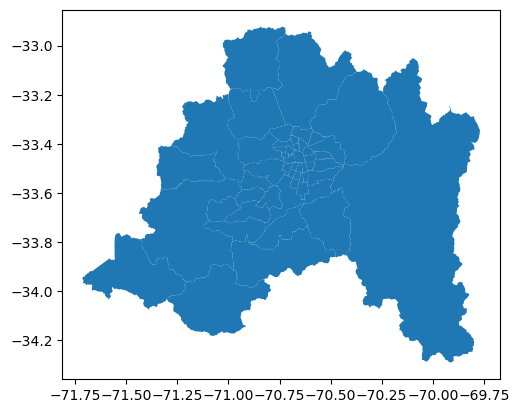

In [49]:
comunas.plot()

In [53]:
print(comunas.shape)
print(comunas.crs)
comunas.head(3)

(52, 7)
EPSG:4674


,CUT,N_REGION,N_PROVINCI,N_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13101,METROPOLITANA,SANTIAGO,SANTIAGO,0.243093,0.002242,"POLYGON ((-70.66533 -33.42822, -70.66492 -33.4..."
1,13102,METROPOLITANA,SANTIAGO,CERRILLOS,0.204707,0.001628,"POLYGON ((-70.71265 -33.48103, -70.71249 -33.4..."
2,13103,METROPOLITANA,SANTIAGO,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."


In [54]:
mapa_delitos = comunas.merge(rm_completo, left_on='CUT', right_on='cut_comuna', how='left')

print('Filas en mapa_delitos:', len(mapa_delitos))
print('Comunas sin dato de tasa tras el cruce:', mapa_delitos['tasa_100k'].isna().sum())
mapa_delitos[['N_COMUNA', 'total_delitos', 'poblacion', 'tasa_100k']].head()

Filas en mapa_delitos: 52
Comunas sin dato de tasa tras el cruce: 0


,N_COMUNA,total_delitos,poblacion,tasa_100k
0,SANTIAGO,48285.039,438856,11002.5
1,CERRILLOS,7014.000,85041,8247.8
2,CERRO NAVIA,6829.000,127250,5366.6
3,CONCHALÍ,6393.000,121587,5258.0
4,EL BOSQUE,8242.000,155257,5308.6


In [55]:
from libpysal.weights import Queen

w = Queen.from_dataframe(mapa_delitos, use_index=False)
w.transform = 'r'

print('Comunas:', w.n)
print('Vecinos promedio por comuna:', round(sum(w.cardinalities.values()) / w.n, 1))
print('Comunas sin ningún vecino (islas):', len([k for k, v in w.cardinalities.items() if v == 0]))

Comunas: 52
Vecinos promedio por comuna: 5.5
Comunas sin ningún vecino (islas): 0


### Celda 1 — Índice de Moran global: ¿hay un patrón espacial real, o podría ser azar?

In [57]:
## info de la libreria: https://pysal.org/notebooks/viz/splot/esda_morans_viz.html

In [58]:
!pip install esda libpysal

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.7 MB/s eta 0:00:00

  Attempting uninstall: shapely

    Found existing installation: shapely 2.0.6

    Uninstalling shapely-2.0.6:

      Successfully uninstalled shapely-2.0.6

   ---------------------------------------- 0/2 [shapely]
   ---------------------------------------- 0/2 [shapely]
   ---------------------------------------- 0/2 [shapely]
   ---------------------------------------- 0/2 [shapely]
   -------------------- ------------------- 1/2 [esda]
   -------------------- ------------------- 1/2 [esda]
   ---------------------------------------- 2/2 [esda]



In [59]:
from esda.moran import Moran

y = mapa_delitos['tasa_100k'].values
moran = Moran(y, w, permutations=999)

print(f'Moran I: {moran.I:.3f}')
print(f'p-valor (999 permutaciones): {moran.p_sim:.4f}')

Moran I: 0.196
p-valor (999 permutaciones): 0.0110


Moran I = 0,196 — positivo, aunque moderado (no extremadamente alto). Indica que hay una tendencia real a que comunas con tasas de delito parecidas estén geográficamente cerca unas de otras — el patrón no está repartido al azar en el mapa.

p-valor = 0,011 — está por debajo del umbral estándar de 0,05, así que ese patrón es estadísticamente significativo: la probabilidad de que un resultado así (o más extremo) salga por puro azar, si la tasa de delitos estuviera distribuida aleatoriamente en el territorio, es de solo 1,1%.

Traducción para decir en clase, en una frase: "La concentración espacial de delitos en la RM que vemos en el ranking de comunas no es casualidad estadística — el test de Moran lo confirma con un 98,9% de confianza. Hay un patrón territorial real, aunque moderado, no extremo."

### Ahora LISA — para saber en qué comunas específicas se concentra esa autocorrelación:

In [60]:
from esda.moran import Moran_Local

lisa = Moran_Local(y, w, permutations=999, seed=1)

mapa_delitos['lisa_cuadrante'] = lisa.q
mapa_delitos['lisa_significativo'] = lisa.p_sim < 0.05

mapa_delitos['cluster'] = 'No significativo'
mapa_delitos.loc[(mapa_delitos.lisa_cuadrante == 1) & mapa_delitos.lisa_significativo, 'cluster'] = 'Alto-Alto (foco caliente)'
mapa_delitos.loc[(mapa_delitos.lisa_cuadrante == 3) & mapa_delitos.lisa_significativo, 'cluster'] = 'Bajo-Bajo (foco frío)'
mapa_delitos.loc[(mapa_delitos.lisa_cuadrante == 2) & mapa_delitos.lisa_significativo, 'cluster'] = 'Bajo-Alto (atípico)'
mapa_delitos.loc[(mapa_delitos.lisa_cuadrante == 4) & mapa_delitos.lisa_significativo, 'cluster'] = 'Alto-Bajo (atípico)'

mapa_delitos['cluster'].value_counts()

cluster
No significativo             40
Alto-Alto (foco caliente)     6
Bajo-Bajo (foco frío)         3
Bajo-Alto (atípico)           2
Alto-Bajo (atípico)           1
Name: count, dtype: int64

Buen resultado, coherente con un Moran moderado (0,196): la mayoría de las comunas (40 de 52) no muestra un patrón local significativo por sí sola, pero hay 6 comunas que forman un foco caliente real — un cluster de tasas altas rodeadas de tasas altas, estadísticamente confirmado, no solo "se ven oscuras en el mapa".

In [61]:
# Mirar el detalle de cada tipo de cluster
print("FOCO CALIENTE (Alto-Alto):")
print(mapa_delitos[mapa_delitos['cluster'] == 'Alto-Alto (foco caliente)'][['N_COMUNA', 'tasa_100k']].sort_values('tasa_100k', ascending=False))

print("\nFOCO FRÍO (Bajo-Bajo):")
print(mapa_delitos[mapa_delitos['cluster'] == 'Bajo-Bajo (foco frío)'][['N_COMUNA', 'tasa_100k']])

print("\nATÍPICOS (una comuna que no calza con sus vecinas):")
print(mapa_delitos[mapa_delitos['cluster'].isin(['Bajo-Alto (atípico)', 'Alto-Bajo (atípico)'])][['N_COMUNA', 'tasa_100k', 'cluster']])

FOCO CALIENTE (Alto-Alto):
            N_COMUNA  tasa_100k
0           SANTIAGO    11002.5
5   ESTACIÓN CENTRAL     8846.2
26          RECOLETA     8438.4
25     QUINTA NORMAL     7124.0
7      INDEPENDENCIA     6597.2
29        SAN MIGUEL     6310.5

FOCO FRÍO (Bajo-Bajo):
        N_COMUNA  tasa_100k
14  LO BARNECHEA     3230.3
35        COLINA     4702.4
44      CURACAVÍ     5715.9

ATÍPICOS (una comuna que no calza con sus vecinas):
               N_COMUNA  tasa_100k              cluster
19                ÑUÑOA     5652.9  Bajo-Alto (atípico)
20  PEDRO AGUIRRE CERDA     5480.8  Bajo-Alto (atípico)
34    SAN JOSÉ DE MAIPO     6931.9  Alto-Bajo (atípico)


El foco caliente confirma el pericentro, con estadística formal

Santiago, Estación Central, Recoleta, Quinta Normal, Independencia, San Miguel — es un bloque geográfico compacto y reconocible: el anillo pericentral de la RM. No es una lista aleatoria de comunas con tasa alta desperdigadas por el mapa; es un cluster territorial real, confirmado por LISA. Aquí puedes retomar la explicación de la población flotante que dimos antes: son comunas de alta densidad diurna (oficinas, universidades, comercio, terminales de transporte), y probablemente parte de esta concentración responde a exposición de población flotante, no solo a población residente.

El foco frío tiene una lectura distinta para cada comuna — cuidado con generalizar

Lo Barnechea, Colina y Curacaví no son "iguales" solo porque caigan en la misma categoría estadística:

Lo Barnechea es una comuna de altos ingresos, con baja densidad y baja exposición peatonal — coherente con tasa baja "real".
Colina y Curacaví son las mismas comunas periurbanas que en la clase de siniestros salieron con la severidad más alta de toda la RM (Colina llegó a 3,97, la más letal de los 6 clusters de KMeans). Aquí, en cambio, tienen baja tasa de delitos.

Esto es oro puro para la clase: el mismo territorio puede ser de alto riesgo en una dimensión (siniestros de tránsito, por velocidad y ruralidad) y de bajo riesgo en otra (delitos, por baja densidad poblacional y poca oportunidad de robo/hurto). Es la mejor evidencia que vas a tener de por qué "seguridad urbana" no es una sola variable, y por qué cada plan (de tránsito, de prevención del delito) necesita su propio diagnóstico espacial.

Los tres atípicos son el material más rico para discutir en vivo
Ñuñoa y Pedro Aguirre Cerda (Bajo-Alto): tienen tasa relativamente baja pero están rodeadas de vecinas con tasa alta — probablemente ambas limitan con parte del cluster caliente (Ñuñoa con Santiago/Providencia; PAC con San Miguel/Estación Central) sin "contagiarse" del patrón de sus vecinas.
San José de Maipo (Alto-Bajo): el caso inverso y más interesante — tasa alta (6.931,9, la tercera más alta de toda la RM) rodeada de comunas con tasa baja. Es la comuna cordillerana, muy grande en superficie y con poca población — mismo problema de denominador chico que discutimos antes en siniestros: con poca población residente, unos pocos delitos bastan para disparar la tasa.

Para clase, la pregunta que le puedes lanzar al curso con este último caso: "¿San José de Maipo es realmente peligrosa, o es el mismo problema del denominador que vimos con las comunas rurales chicas en la clase de siniestros?" — buena forma de que ellos mismos apliquen el pensamiento crítico que llevas enseñando toda la semana.

In [66]:
mapa_delitos_wgs84 = mapa_delitos.to_crs('EPSG:4326')

In [67]:
import folium

# Centrar el mapa en el centroide de todas las comunas
centro = mapa_delitos_wgs84.geometry.centroid
mapa = folium.Map(location=[centro.y.mean(), centro.x.mean()], zoom_start=10, tiles='CartoDB positron')

colores = {
    'Alto-Alto (foco caliente)': '#B2182B',
    'Bajo-Bajo (foco frío)':     '#2166AC',
    'Bajo-Alto (atípico)':       '#92C5DE',
    'Alto-Bajo (atípico)':       '#F4A582',
    'No significativo':          '#F0F0F0',
}

folium.GeoJson(
    mapa_delitos_wgs84,
    style_function=lambda feature: {
        'fillColor': colores[feature['properties']['cluster']],
        'color': 'white', 'weight': 0.8, 'fillOpacity': 0.75,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['N_COMUNA', 'tasa_100k', 'cluster'],
        aliases=['Comuna:', 'Tasa por 100.000 hab.:', 'Cluster LISA:'],
        localize=True,
    ),
).add_to(mapa)

mapa

C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\3508199488.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centro = mapa_delitos_wgs84.geometry.centroid


C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\77464031.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=9)
C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\77464031.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=9)


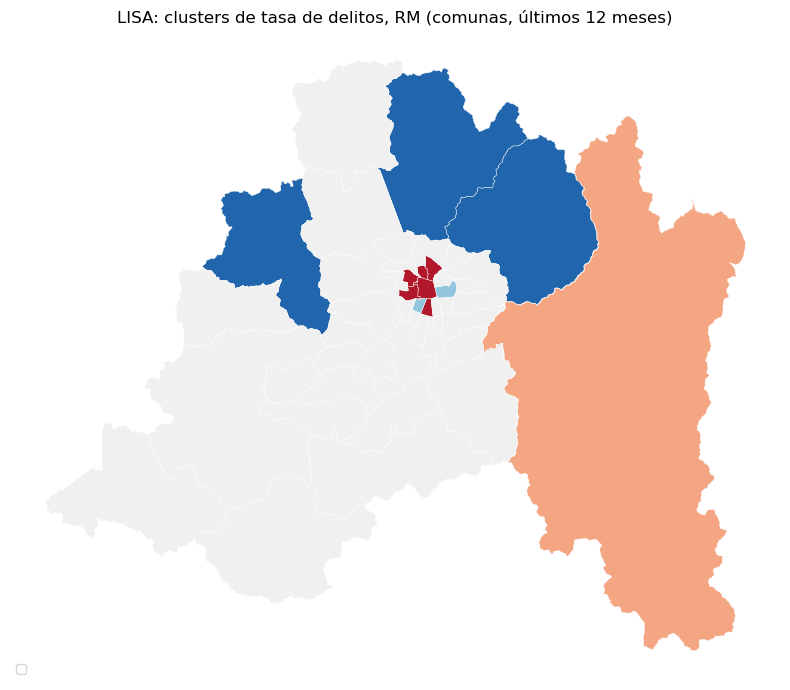

In [65]:
import matplotlib.pyplot as plt

colores = {
    'Alto-Alto (foco caliente)': '#B2182B',  # rojo oscuro / rojo ladrillo
    'Bajo-Bajo (foco frío)':     '#2166AC',  # azul oscuro / azul marino
    'Bajo-Alto (atípico)':       '#92C5DE',  # celeste / azul cielo claro
    'Alto-Bajo (atípico)':       '#F4A582',  # naranja claro / durazno
    'No significativo':          '#F0F0F0',  # gris muy claro / casi blanco
}

fig, ax = plt.subplots(figsize=(8, 9))
for cat, color in colores.items():
    mapa_delitos[mapa_delitos['cluster'] == cat].plot(ax=ax, color=color, edgecolor='white', linewidth=0.3, label=cat)
ax.legend(loc='lower left', fontsize=9)
ax.set_title('LISA: clusters de tasa de delitos, RM (comunas, últimos 12 meses)')
ax.set_axis_off()
plt.tight_layout(); plt.show()

In [68]:
from esda.getisord import G_Local

# star=True es la versión Gi* (incluye la propia comuna en la suma con sus vecinas, no solo las vecinas)
gi_star = G_Local(y, w, star=True, permutations=999, seed=1)

mapa_delitos['gi_z'] = gi_star.Zs
mapa_delitos['gi_p'] = gi_star.p_sim

# Clasificar en hot / cold spot según significancia (mismo umbral de siempre: p < 0.05)
mapa_delitos['gi_cluster'] = 'No significativo'
mapa_delitos.loc[(mapa_delitos.gi_z > 0) & (mapa_delitos.gi_p < 0.05), 'gi_cluster'] = 'Hot spot'
mapa_delitos.loc[(mapa_delitos.gi_z < 0) & (mapa_delitos.gi_p < 0.05), 'gi_cluster'] = 'Cold spot'

mapa_delitos['gi_cluster'].value_counts()

C:\Users\valeria.ulloa\anaconda3\envs\geo_env\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


gi_cluster
No significativo    40
Hot spot             8
Cold spot            4
Name: count, dtype: int64

encontró 8 hot spots (contra los 6 de LISA) y 4 cold spots (contra los 3 de LISA) — más comunas "calientes" o "frías" en total, porque Gi* suma el vecindario completo en vez de comparar comuna contra comuna.

In [69]:
# Comparación directa: qué dice LISA vs qué dice Gi* para cada comuna
comparacion = mapa_delitos[['N_COMUNA', 'tasa_100k', 'cluster', 'gi_cluster']].copy()

# Nos interesan sobre todo las comunas donde los dos métodos NO coinciden
comparacion['coinciden'] = (
    ((comparacion['cluster'] == 'Alto-Alto (foco caliente)') & (comparacion['gi_cluster'] == 'Hot spot')) |
    ((comparacion['cluster'] == 'Bajo-Bajo (foco frío)') & (comparacion['gi_cluster'] == 'Cold spot')) |
    ((comparacion['cluster'] == 'No significativo') & (comparacion['gi_cluster'] == 'No significativo'))
)

print("Comunas donde LISA y Getis-Ord Gi* NO coinciden (el caso interesante para clase):")
print(comparacion[~comparacion['coinciden']].sort_values('tasa_100k', ascending=False))

Comunas donde LISA y Getis-Ord Gi* NO coinciden (el caso interesante para clase):
               N_COMUNA  tasa_100k              cluster gi_cluster  coinciden
34    SAN JOSÉ DE MAIPO     6931.9  Alto-Bajo (atípico)  Cold spot      False
19                ÑUÑOA     5652.9  Bajo-Alto (atípico)   Hot spot      False
20  PEDRO AGUIRRE CERDA     5480.8  Bajo-Alto (atípico)   Hot spot      False


C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\4192038874.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(loc='lower left', fontsize=7)
C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\4192038874.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='lower left', fontsize=7)
C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\4192038874.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[1].legend(loc='lower left', fontsize=9)
C:\Users\valeria.ulloa\AppData\Local\Temp\ipykernel_7608\4192038874.py:14: UserWarning: 

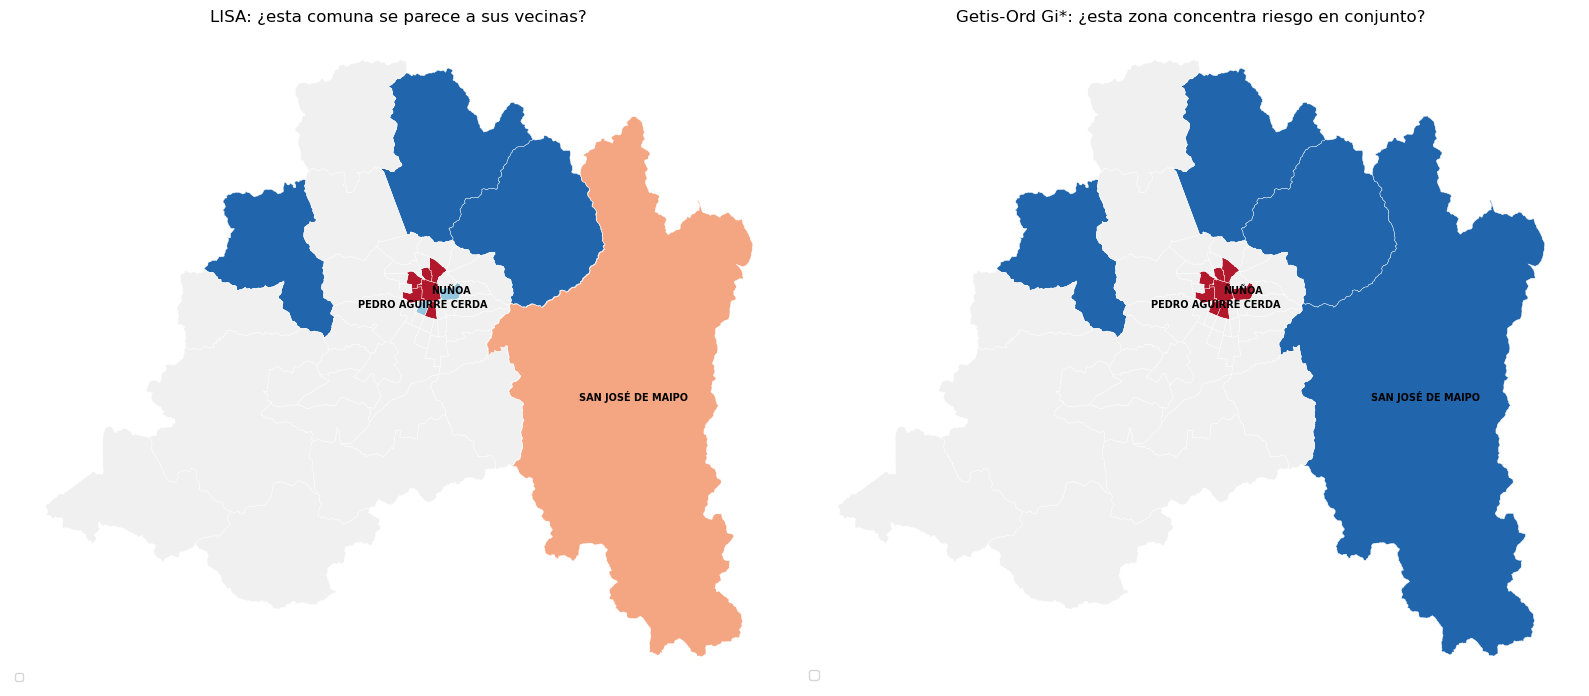

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Mapa 1: LISA
for cat, color in colores.items():
    mapa_delitos[mapa_delitos['cluster'] == cat].plot(ax=axes[0], color=color, edgecolor='white', linewidth=0.3, label=cat)
axes[0].set_title('LISA: ¿esta comuna se parece a sus vecinas?', fontsize=12)
axes[0].legend(loc='lower left', fontsize=7)
axes[0].set_axis_off()

# Mapa 2: Getis-Ord Gi*
for cat, color in colores_gi.items():
    mapa_delitos[mapa_delitos['gi_cluster'] == cat].plot(ax=axes[1], color=color, edgecolor='white', linewidth=0.3, label=cat)
axes[1].set_title('Getis-Ord Gi*: ¿esta zona concentra riesgo en conjunto?', fontsize=12)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].set_axis_off()

# Etiquetar los tres casos discrepantes en ambos mapas, para que se vea el contraste
discrepantes = mapa_delitos[mapa_delitos['N_COMUNA'].isin(['SAN JOSÉ DE MAIPO', 'ÑUÑOA', 'PEDRO AGUIRRE CERDA'])]
for ax in axes:
    for _, fila in discrepantes.iterrows():
        c = fila.geometry.centroid
        ax.annotate(fila['N_COMUNA'], xy=(c.x, c.y), ha='center', fontsize=7, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('comparacion_lisa_gi.png', dpi=150, bbox_inches='tight')
plt.show()

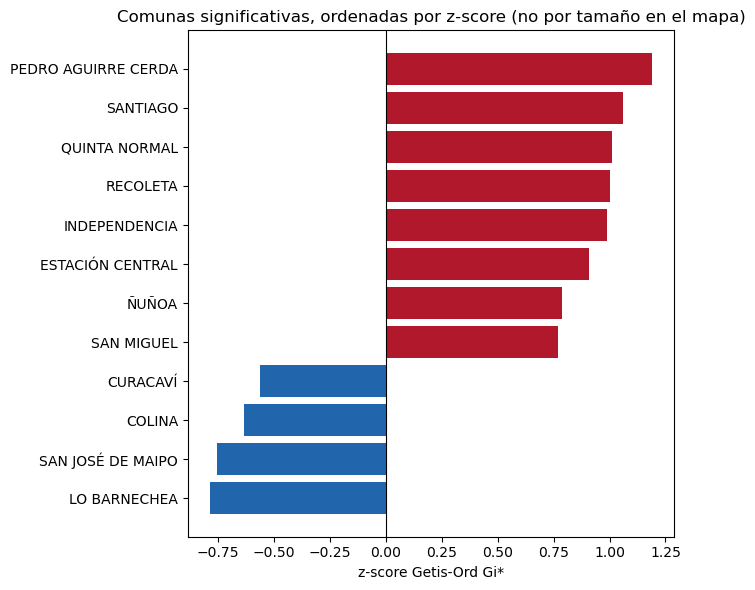

In [72]:
fig, ax = plt.subplots(figsize=(7, 6))
top_gi = mapa_delitos[mapa_delitos['gi_cluster'] != 'No significativo'].sort_values('gi_z')
colores_barra = top_gi['gi_cluster'].map({'Hot spot': '#B2182B', 'Cold spot': '#2166AC'})
ax.barh(top_gi['N_COMUNA'], top_gi['gi_z'], color=colores_barra)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('z-score Getis-Ord Gi*')
ax.set_title('Comunas significativas, ordenadas por z-score (no por tamaño en el mapa)')
plt.tight_layout(); plt.show()